# 1주차 EDA — 광역 22개 변수 분석

> 계획서 v5.1 §9 1주차 검증 포인트: **결측·이상치 비율 확인 / SHAP 작동 / freeze 결정 사유 기록**

## 본 노트북의 목표

1. 1차 EDA — 결측·이상치·기초 통계로 **명백한 outlier 변수** 1차 식별
2. 시계열 플롯 — 변수별 추이와 위기 구간(2020 코로나·2022 인상기·2024 계엄) 시각적 확인
3. 타겟 (`kr_treasury_10y`) 분석 — 레벨·변화량(Δy)·자기상관·분포
4. 1차 상관 분석 — 타겟 Δy 와 다른 변수의 1차 상관계수
5. 환율 (`krw_usd`) 사전 EDA — 5주차 ablation 비교 준비
6. **SHAP Hello World** — XGBoost + TreeExplainer 로 분석 흐름 동작 확인
7. 1주차 말 **변수 8개 freeze** 결정 (사유는 `VALIDATION_LOG.md` 에 기록)

## 후속 단계

- **2주차** (`02_feature_selection.ipynb`): VIF, Granger 인과성, 단계 축소 산출물 3건 마감
- **3주차** (`03_baselines.ipynb`): 변수 freeze 확정 + Naive/ARIMA/XGBoost 베이스라인

---

## 0. 환경 설정

In [2]:
# === 의존성 자동 체크 (없으면 자동 설치) ===
# 첫 실행 시 누락 패키지 자동 설치. 이미 설치돼 있으면 즉시 통과.
# 새 PC / 새 가상환경에서 노트북 실행 시 ModuleNotFoundError 방지.
import importlib.util, subprocess, sys

REQUIRED = {
    'shap':        'shap',
    'xgboost':     'xgboost',
    'statsmodels': 'statsmodels',
    'matplotlib':  'matplotlib',
    'seaborn':     'seaborn',
    'yfinance':    'yfinance',
    'dotenv':      'python-dotenv',  # import 이름과 pip 이름이 다름
}

for _import_name, _pip_name in REQUIRED.items():
    if importlib.util.find_spec(_import_name) is None:
        print(f'  Installing {_pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pip_name])

print('✅ 의존성 체크 완료\n')

# === 본 import ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 경로 설정 (프로젝트 루트에서 notebooks/ 한 단계 위로)
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# pandas display
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')

✅ 의존성 체크 완료

PROJECT_ROOT: c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast
DATA_DIR exists: True


---

## 1. 데이터 로드

- `wide_daily.csv` — NaN 유지 (EDA 의 결측 패턴 분석용)
- `wide_daily_filled.csv` — 월별 변수 forward fill 적용 (모델 학습용 초안)
- `data_dictionary.csv` — 변수 메타데이터

In [3]:
wide = pd.read_csv(
    DATA_DIR / 'interim' / 'wide_daily.csv',
    index_col='date', parse_dates=['date']
)
wide_filled = pd.read_csv(
    DATA_DIR / 'interim' / 'wide_daily_filled.csv',
    index_col='date', parse_dates=['date']
)
dd = pd.read_csv(DATA_DIR / 'raw' / 'data_dictionary.csv')

print(f'wide.shape:        {wide.shape}')
print(f'wide_filled.shape: {wide_filled.shape}')
print(f'기간: {wide.index.min().date()} ~ {wide.index.max().date()}')
print(f'영업일 수: {len(wide):,}')
print(f'\n변수 분류 분포:')
print(dd['category'].value_counts())
dd

wide.shape:        (4174, 24)
wide_filled.shape: (4174, 24)
기간: 2010-01-01 ~ 2025-12-31
영업일 수: 4,174

변수 분류 분포:
category
국내금리     6
국내인플     3
미국금리     3
국내실물     2
미국인플     2
위험       2
자산       2
타겟       1
검증용      1
원자재      1
글로벌달러    1
Name: count, dtype: int64


,variable,category,description,source,code,frequency
0,kr_treasury_10y,타겟,국고채 10년물,ECOS,817Y002/010210000,D
1,kr_treasury_5y,국내금리,국고채 5년물,ECOS,817Y002/010200001,D
2,kr_treasury_3y,국내금리,국고채 3년물,ECOS,817Y002/010200000,D
3,kr_treasury_1y,국내금리,국고채 1년물,ECOS,817Y002/010190000,D
4,kr_corp_aa3y,국내금리,회사채 AA- 3년,ECOS,817Y002/010300000,D
5,kr_cd_91d,국내금리,CD 91일,ECOS,817Y002/010502000,D
6,kr_base_rate,국내금리,한국은행 기준금리,ECOS,722Y001/0101000,D
7,krw_usd,검증용,원/달러 환율 종가,ECOS,731Y001/0000001,D
8,kr_cpi,국내인플,소비자물가지수 총지수,ECOS,901Y009/0,M
9,kr_cpi_core,국내인플,근원 CPI (농산물 및 석유류 제외),ECOS,901Y010/QB,M


---

## 2. 결측치 분석

### 예상 패턴
- **월별 변수**(CPI, PPI, BSI 등): 영업일 인덱스 기준 ~96.7% 결측 (정상 — 1개월에 1포인트만)
- **일별 변수**: 한·미 영업일 차이로 3~6% 결측
- `kr_base_rate`, `us_fed_funds`: 0% (매일 동일값 유지)

이상 신호: **30% 이상 결측**인 일별 변수 → 데이터 가용성 점검 필요

In [4]:
miss_pct = (wide.isna().mean() * 100).sort_values(ascending=False)
miss_df = miss_pct.to_frame('결측 (%)').reset_index().rename(columns={'index': 'variable'})
miss_df = miss_df.merge(dd[['variable', 'category', 'frequency']], on='variable', how='left')
miss_df['결측 (%)'] = miss_df['결측 (%)'].round(1)

# 색상: 일별 변수가 30% 넘으면 경고
def flag(row):
    if row['frequency'] == 'D' and row['결측 (%)'] > 30:
        return '🔴 점검 필요'
    elif row['frequency'] == 'M' and row['결측 (%)'] < 90:
        return '⚠️ 비정상'
    elif row['결측 (%)'] > 95 and row['frequency'] == 'M':
        return '✅ 월별 정상'
    else:
        return '✅ 정상'
miss_df['상태'] = miss_df.apply(flag, axis=1)
miss_df

,variable,결측 (%),category,frequency,상태
0,us_cpi,96.7,미국인플,M,✅ 월별 정상
1,kr_cpi_core,96.7,국내인플,M,✅ 월별 정상
2,kr_cpi,96.7,국내인플,M,✅ 월별 정상
3,kr_industrial_prod,96.7,국내실물,M,✅ 월별 정상
4,kr_mfg_bsi_outlook,96.7,국내실물,M,✅ 월별 정상
5,kr_ppi,96.7,국내인플,M,✅ 월별 정상
6,kospi,5.7,자산,D,✅ 정상
7,kr_cd_91d,5.2,국내금리,D,✅ 정상
8,kr_treasury_3y,5.2,국내금리,D,✅ 정상
9,kr_treasury_5y,5.2,국내금리,D,✅ 정상


---

## 3. 시계열 플롯 — 카테고리별

변수별 추이 + 위기 구간 시각적 확인. **wide_filled** 사용 (월별 변수 ffill 후).

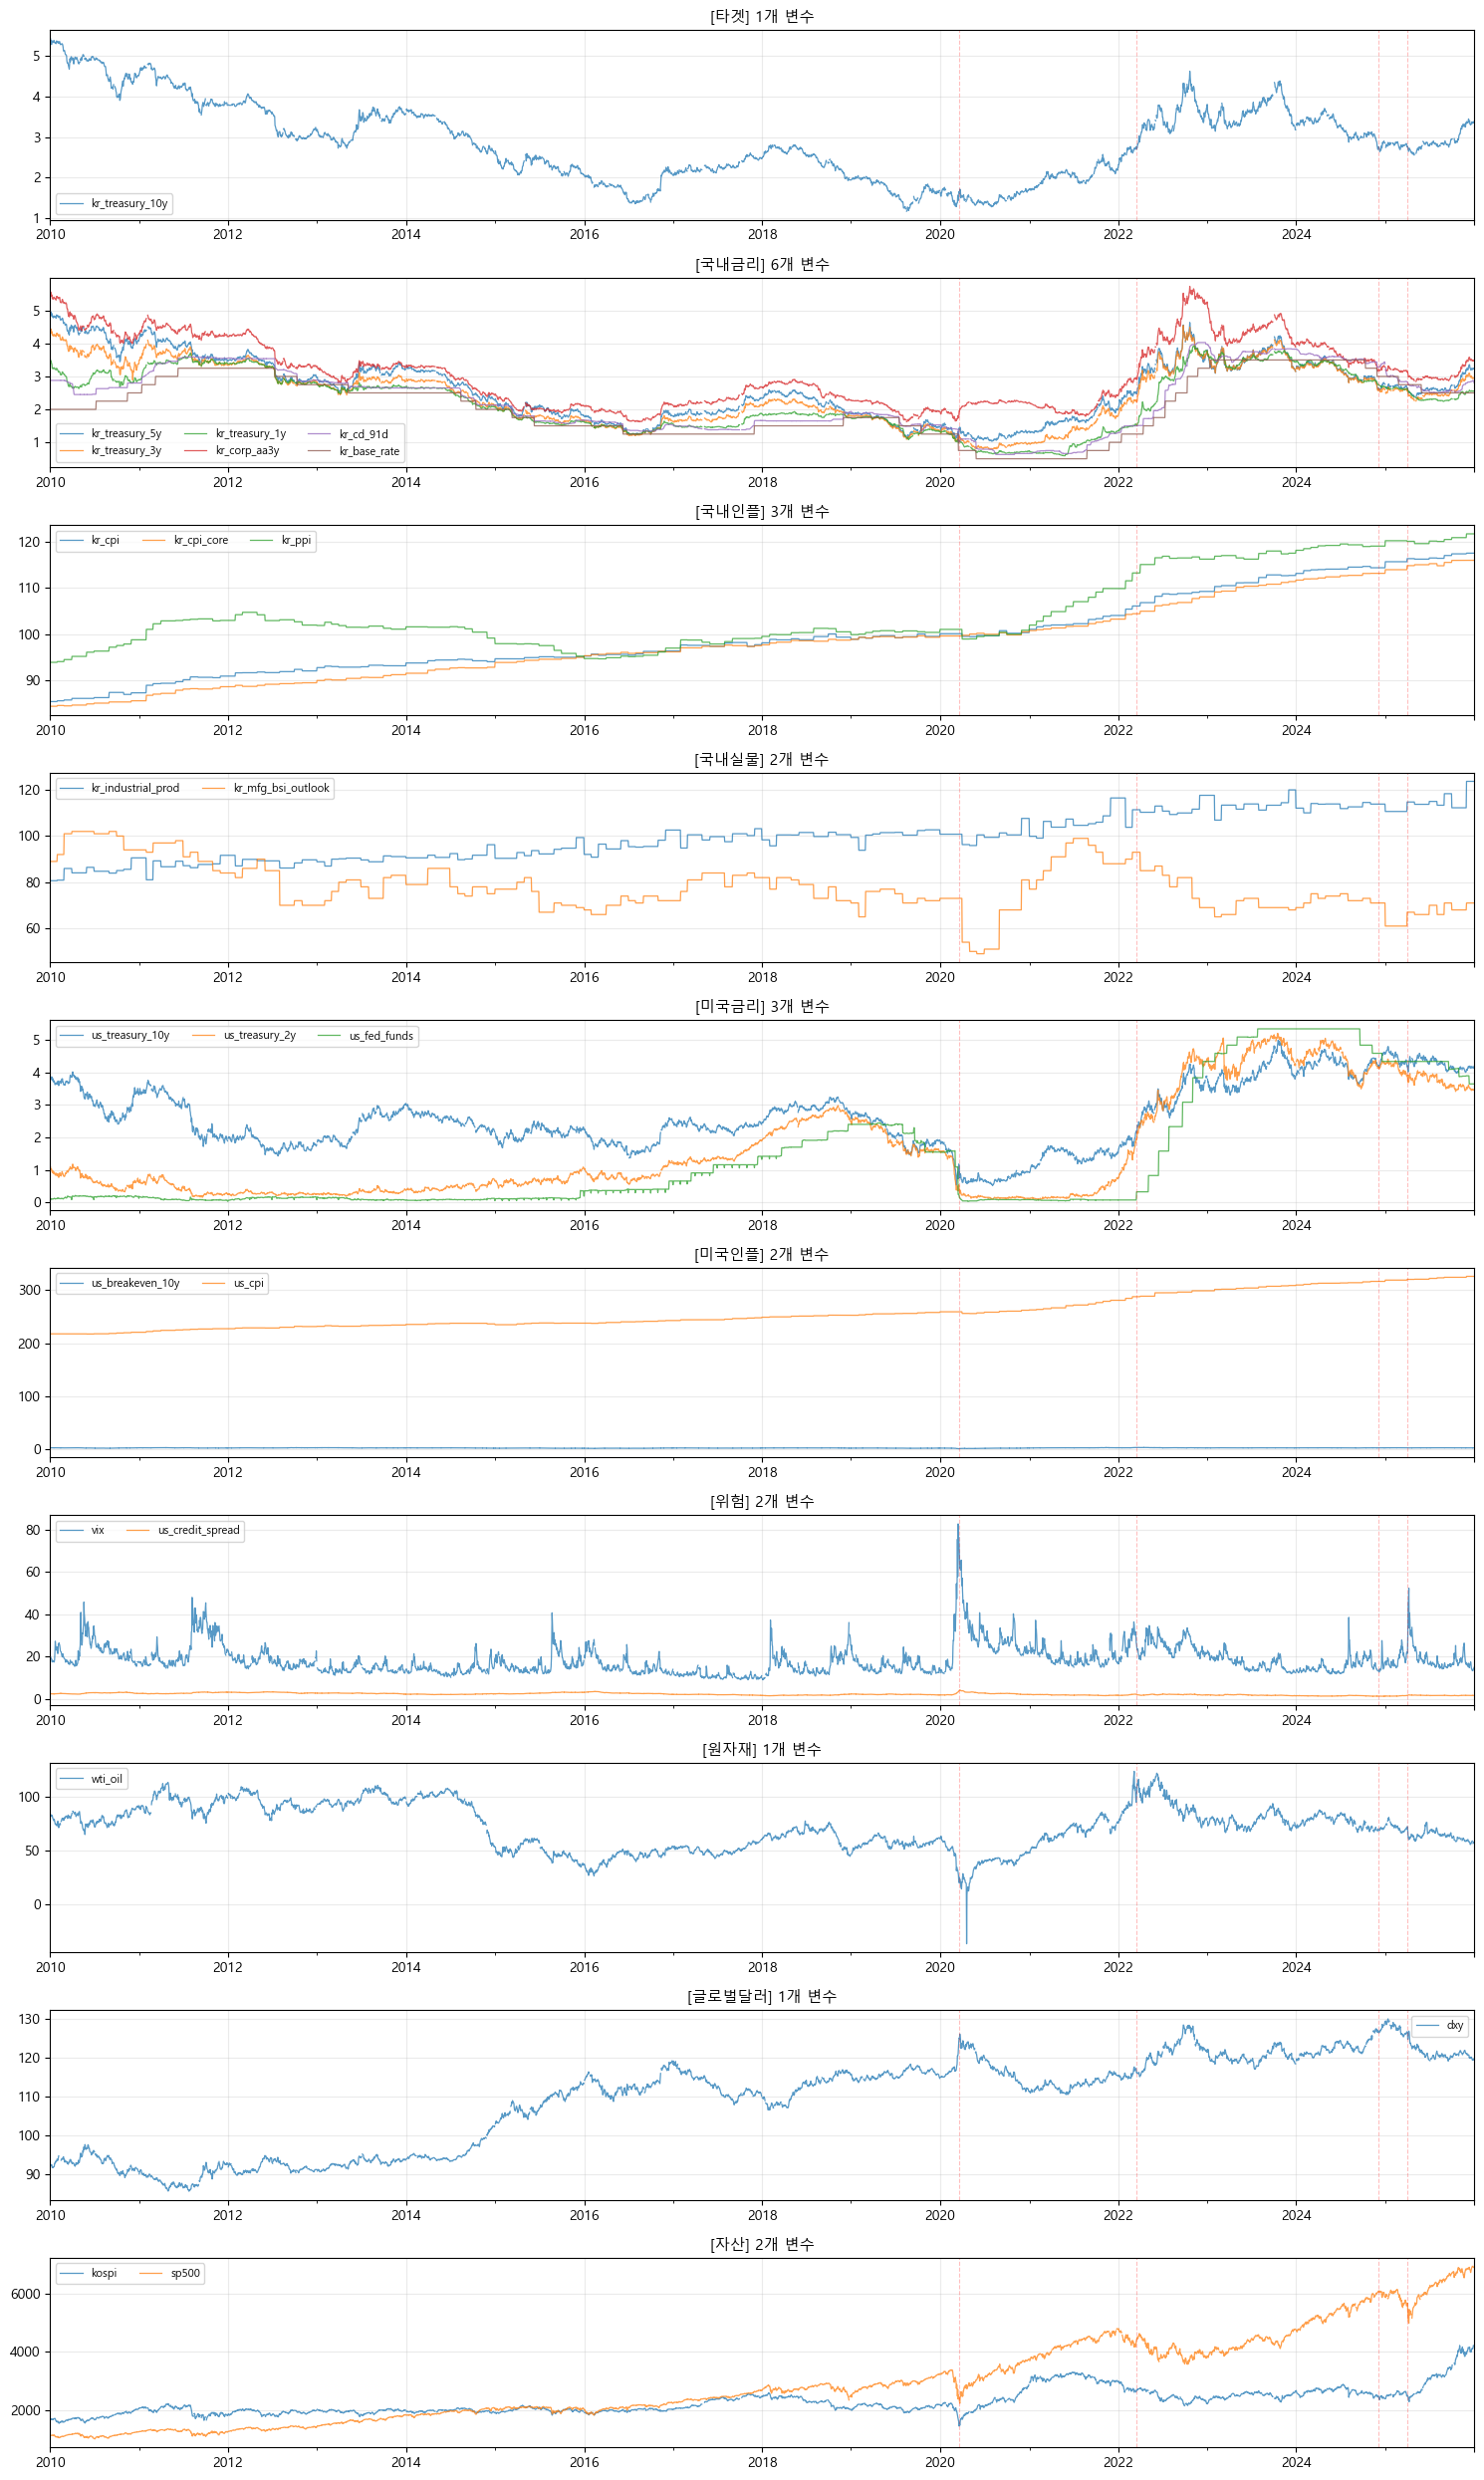

In [5]:
# 위기 구간 라벨 (계획서 §4.4 정량 정의 외에 시각 참고용)
crisis_events = {
    '2020-03-19': '코로나 충격',
    '2022-03-16': 'Fed 인상 시작',
    '2024-12-03': '계엄 사태',
    '2025-04-01': '고환율 국면',
}

categories = dd['category'].unique()
categories = [c for c in categories if c != '검증용']  # 환율은 §6에서 별도

fig, axes = plt.subplots(len(categories), 1, figsize=(15, 2.5 * len(categories)))
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    cols = dd[dd['category'] == cat]['variable'].tolist()
    cols = [c for c in cols if c in wide_filled.columns]
    wide_filled[cols].plot(ax=ax, alpha=0.75, linewidth=0.9)
    for d, label in crisis_events.items():
        ax.axvline(pd.to_datetime(d), color='red', alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_title(f'[{cat}] {len(cols)}개 변수', fontsize=11)
    ax.legend(loc='best', fontsize=8, ncol=3)
    ax.grid(alpha=0.25)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_timeseries_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 4. 타겟 분석 — `kr_treasury_10y`

### 핵심 통찰 (계획서 §2.1 변경 사유)
- 일별 채권 **레벨**은 자기상관 매우 강함 → Naive 베이스라인 강력.
- 그래서 본 프로젝트는 **변화량 Δy = (y_{t+1} − y_t) × 100 (bp)** 를 타겟으로.

### 점검 항목
1. 레벨과 변화량 비교
2. Δy 분포 (정규성 가정 가능?)
3. Δy 자기상관 (residual 처럼 random 한가?)

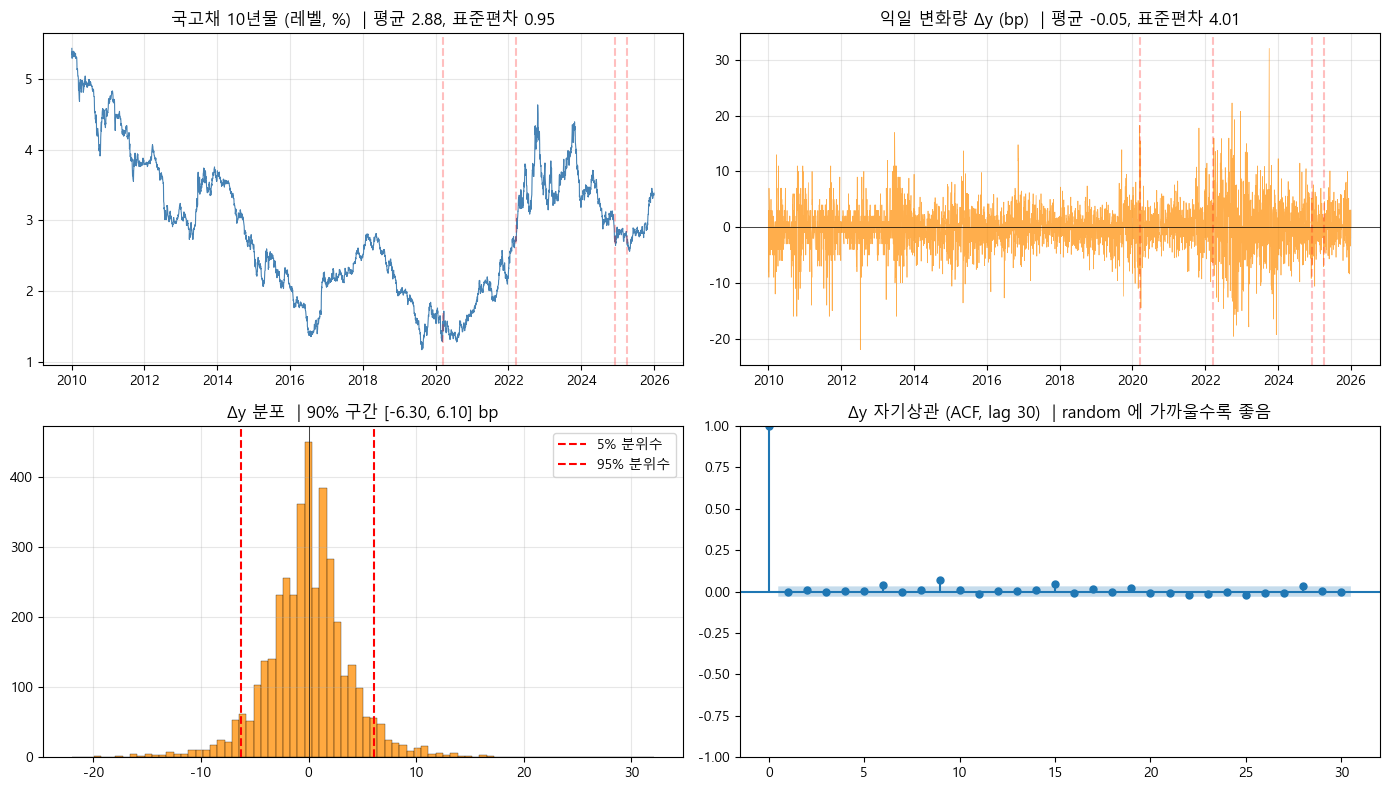


타겟 통계 요약:
  레벨 (%):    평균 2.883, 표준편차 0.945, 범위 [1.17, 5.43]
  변화량 (bp): 평균 -0.052, 표준편차 4.007, 90% 구간 [-6.30, 6.10]
  |Δy| > 5bp 케이스 비율: 15.9%
  |Δy| > 10bp 케이스 비율: 3.1%


In [6]:
target = wide_filled['kr_treasury_10y'].dropna()
delta = target.diff().dropna() * 100  # bp

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1) 레벨
axes[0, 0].plot(target.index, target.values, linewidth=0.8, color='steelblue')
for d in crisis_events:
    axes[0, 0].axvline(pd.to_datetime(d), color='red', alpha=0.25, linestyle='--')
axes[0, 0].set_title(f'국고채 10년물 (레벨, %)  | 평균 {target.mean():.2f}, 표준편차 {target.std():.2f}')
axes[0, 0].grid(alpha=0.3)

# (2) 변화량
axes[0, 1].plot(delta.index, delta.values, linewidth=0.5, color='darkorange', alpha=0.7)
for d in crisis_events:
    axes[0, 1].axvline(pd.to_datetime(d), color='red', alpha=0.25, linestyle='--')
axes[0, 1].axhline(0, color='black', linewidth=0.5)
axes[0, 1].set_title(f'익일 변화량 Δy (bp)  | 평균 {delta.mean():.2f}, 표준편차 {delta.std():.2f}')
axes[0, 1].grid(alpha=0.3)

# (3) Δy 분포
axes[1, 0].hist(delta.values, bins=80, color='darkorange', alpha=0.75, edgecolor='black', linewidth=0.3)
axes[1, 0].axvline(0, color='black', linewidth=0.5)
axes[1, 0].axvline(delta.quantile(0.05), color='red', linestyle='--', label='5% 분위수')
axes[1, 0].axvline(delta.quantile(0.95), color='red', linestyle='--', label='95% 분위수')
axes[1, 0].set_title(f'Δy 분포  | 90% 구간 [{delta.quantile(0.05):.2f}, {delta.quantile(0.95):.2f}] bp')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (4) 자기상관 ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(delta.values, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Δy 자기상관 (ACF, lag 30)  | random 에 가까울수록 좋음')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_target_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n타겟 통계 요약:')
print(f'  레벨 (%):    평균 {target.mean():.3f}, 표준편차 {target.std():.3f}, 범위 [{target.min():.2f}, {target.max():.2f}]')
print(f'  변화량 (bp): 평균 {delta.mean():.3f}, 표준편차 {delta.std():.3f}, 90% 구간 [{delta.quantile(0.05):.2f}, {delta.quantile(0.95):.2f}]')
print(f'  |Δy| > 5bp 케이스 비율: {(delta.abs() > 5).mean() * 100:.1f}%')
print(f'  |Δy| > 10bp 케이스 비율: {(delta.abs() > 10).mean() * 100:.1f}%')

---

## 5. 1차 상관 분석 — 타겟 Δy 와 모든 변수

### 변수 변환
- 일별 변수: 차분 (`.diff()`)
- 월별 변수: ffill 후 차분 (영업일 기준 변화는 0 이 대부분)

### 해석 가이드
- |r| > 0.3: 강한 동시 상관 (potential good predictor)
- |r| < 0.05: 거의 무관 (variable freeze 시 우선 제외 후보)

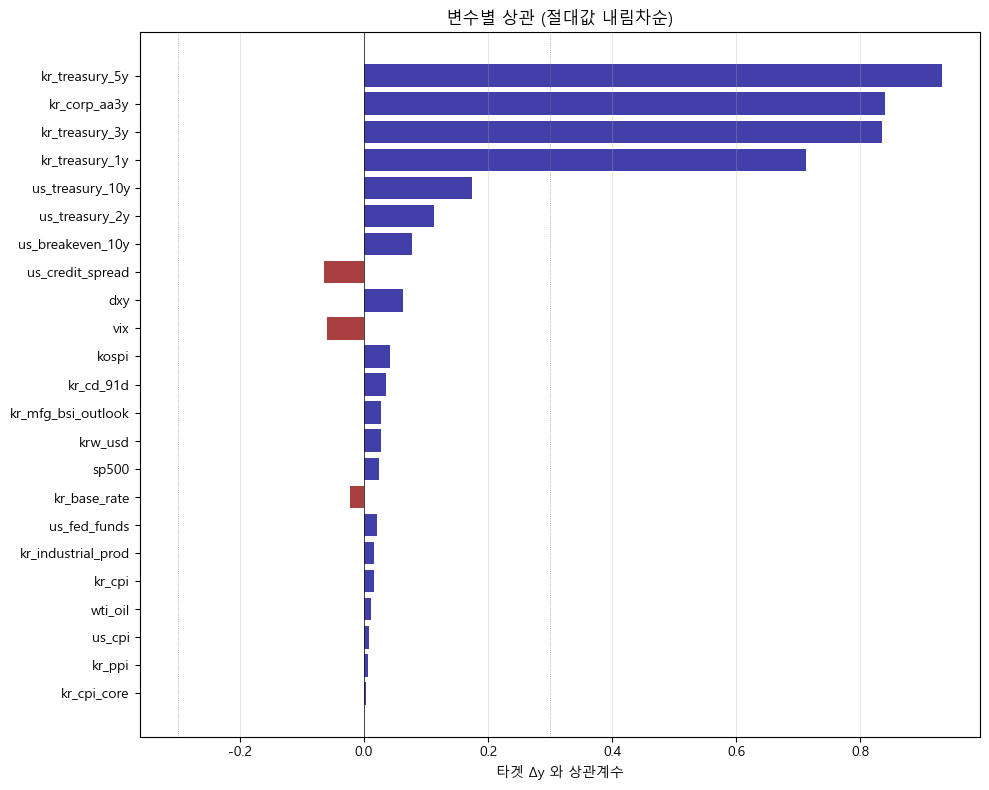

,타겟Δy 와 상관계수
kr_treasury_5y,0.931144
kr_corp_aa3y,0.839072
kr_treasury_3y,0.834279
kr_treasury_1y,0.711801
us_treasury_10y,0.174335
us_treasury_2y,0.113533
us_breakeven_10y,0.078084
us_credit_spread,-0.063740
dxy,0.062585
vix,-0.058970


In [7]:
# 모든 변수의 차분
deltas = wide_filled.diff()
target_delta = deltas['kr_treasury_10y']

corr_with_target = deltas.corrwith(target_delta).drop('kr_treasury_10y').sort_values(ascending=False)
corr_df = corr_with_target.to_frame('타겟Δy 와 상관계수')
corr_df['절대값'] = corr_df['타겟Δy 와 상관계수'].abs()
corr_df = corr_df.sort_values('절대값', ascending=False).drop(columns=['절대값'])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['darkblue' if v > 0 else 'darkred' for v in corr_df['타겟Δy 와 상관계수']]
ax.barh(corr_df.index[::-1], corr_df['타겟Δy 와 상관계수'].values[::-1], color=colors[::-1], alpha=0.75)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(0.3, color='gray', linestyle=':', linewidth=0.5)
ax.axvline(-0.3, color='gray', linestyle=':', linewidth=0.5)
ax.set_xlabel('타겟 Δy 와 상관계수')
ax.set_title('변수별 상관 (절대값 내림차순)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_correlation_with_target.png', dpi=120, bbox_inches='tight')
plt.show()

corr_df.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)

---

## 6. 환율 사전 EDA — `krw_usd`

### 목적 (계획서 §3.4)
- 환율은 **입력 변수에서 의도적 제외** (정부 개입 구조)
- 5주차에 ablation 비교용으로 수집만
- 1주차에는 정부 개입 시점을 시각적으로 확인 → SHAP 사후 분석에 활용

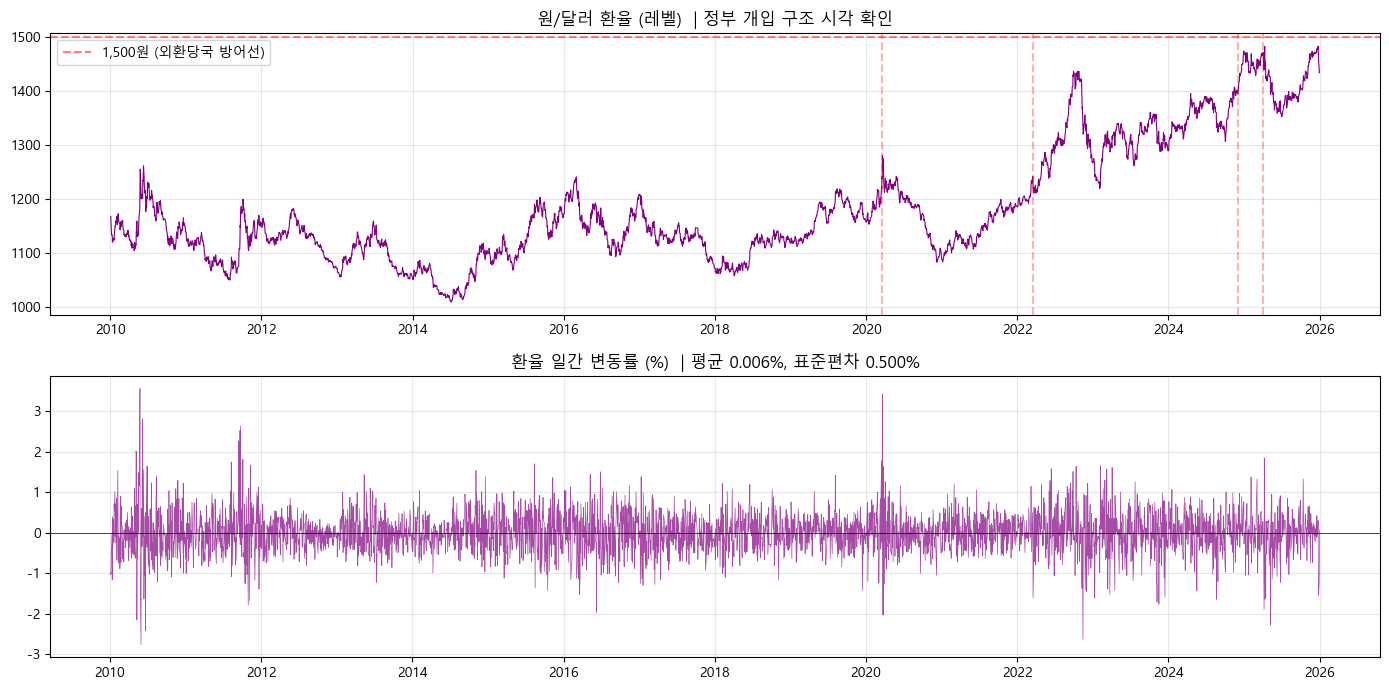


환율 일간 변동률과 타겟Δy 상관: 0.027
  → 5주차 ablation 에서 환율 포함 모델 vs 제외 모델 비교 시 참고


In [8]:
fx = wide_filled['krw_usd'].dropna()
fx_delta = fx.diff() / fx.shift(1) * 100  # 일간 % 변화

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# (1) 레벨
axes[0].plot(fx.index, fx.values, linewidth=0.8, color='purple')
axes[0].axhline(1500, color='red', linestyle='--', alpha=0.5, label='1,500원 (외환당국 방어선)')
for d, label in crisis_events.items():
    axes[0].axvline(pd.to_datetime(d), color='red', alpha=0.3, linestyle='--')
axes[0].set_title('원/달러 환율 (레벨)  | 정부 개입 구조 시각 확인')
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) 일간 변동률
axes[1].plot(fx_delta.index, fx_delta.values, linewidth=0.5, color='purple', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title(f'환율 일간 변동률 (%)  | 평균 {fx_delta.mean():.3f}%, 표준편차 {fx_delta.std():.3f}%')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '04_fx_pre_eda.png', dpi=120, bbox_inches='tight')
plt.show()

# 타겟Δy 와 환율Δ% 의 상관 (정부 개입 영향 1차 진단)
fx_target_corr = fx_delta.corr(target_delta)
print(f'\n환율 일간 변동률과 타겟Δy 상관: {fx_target_corr:.3f}')
print(f'  → 5주차 ablation 에서 환율 포함 모델 vs 제외 모델 비교 시 참고')

---

## 7. SHAP Hello World — XGBoost + TreeExplainer

### 목적 (계획서 §6.2)
- 1주차에 **분석 흐름이 동작**함을 확인
- LSTM-SHAP DeepExplainer 호환성 검증은 4주차로 미룸
- TreeExplainer 는 학부 입문자에게 가장 안정적

### 모델 단순화
- 작은 표본·얕은 트리 — 동작 확인이 목적이지 성능 최적화 X
- 본 모델 학습은 4주차

In [9]:
import xgboost as xgb
import shap

# 학습 샘플 준비 (NaN 제거 후 변화량 타겟)
df = wide_filled.dropna().copy()
df['target_delta'] = df['kr_treasury_10y'].diff()
df = df.dropna()

# 입력에서 환율 제외 (계획서 §3.4)
exclude = ['kr_treasury_10y', 'target_delta', 'krw_usd']
feature_cols = [c for c in df.columns if c not in exclude]
X = df[feature_cols]
y = df['target_delta']

print(f'학습 샘플: {len(X):,} 일,  feature: {len(feature_cols)} 개')
print(f'feature 목록: {feature_cols}')

# 작은 모델 (Hello World 용)
model = xgb.XGBRegressor(
    n_estimators=80, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0
)
model.fit(X, y)

# SHAP — 최근 200일만 (속도)
explainer = shap.TreeExplainer(model)
X_sample = X.iloc[-200:]
shap_values = explainer.shap_values(X_sample)

print(f'\n✅ SHAP 동작 확인 완료. shap_values shape: {shap_values.shape}')

학습 샘플: 3,751 일,  feature: 22 개
feature 목록: ['dxy', 'kospi', 'kr_base_rate', 'kr_cd_91d', 'kr_corp_aa3y', 'kr_cpi', 'kr_cpi_core', 'kr_industrial_prod', 'kr_mfg_bsi_outlook', 'kr_ppi', 'kr_treasury_1y', 'kr_treasury_3y', 'kr_treasury_5y', 'sp500', 'us_breakeven_10y', 'us_cpi', 'us_credit_spread', 'us_fed_funds', 'us_treasury_10y', 'us_treasury_2y', 'vix', 'wti_oil']

✅ SHAP 동작 확인 완료. shap_values shape: (200, 22)


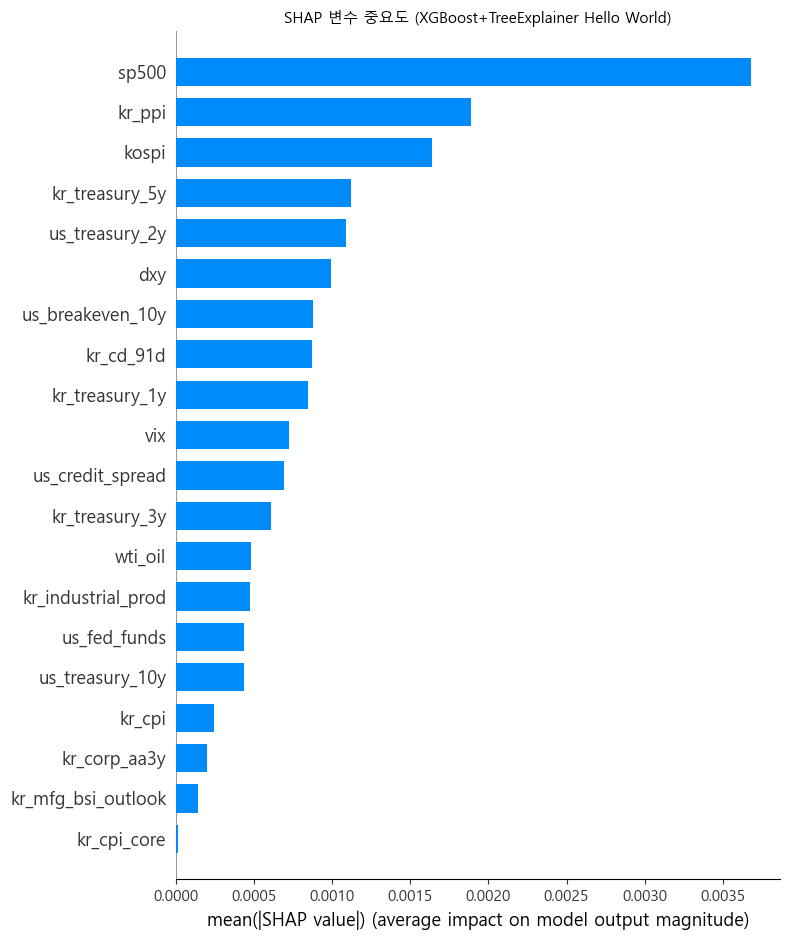

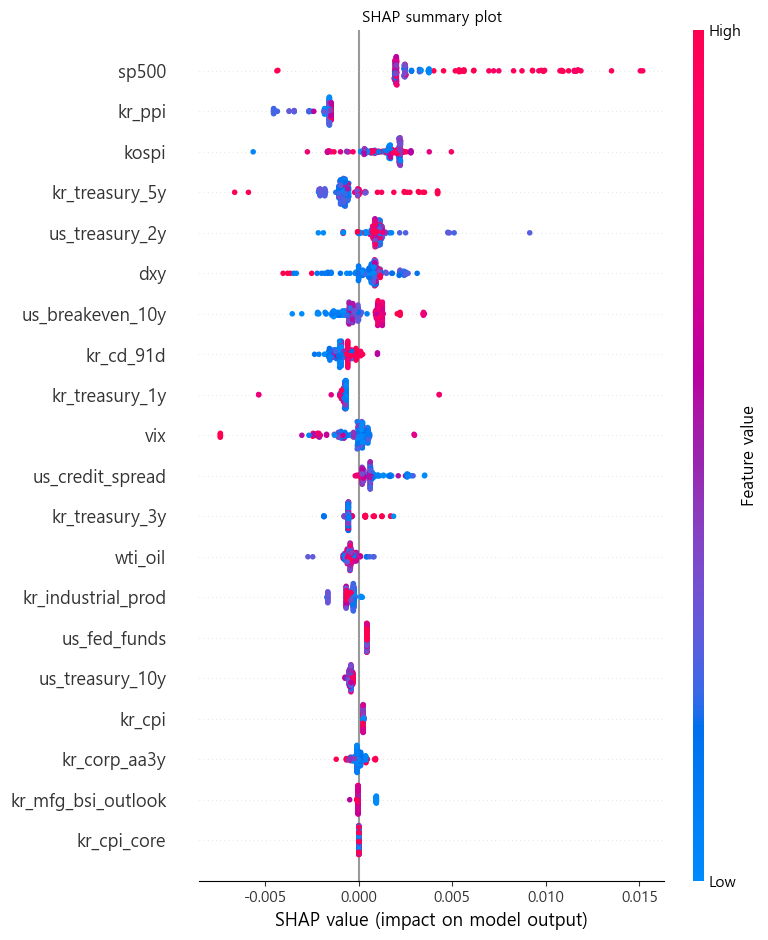

In [10]:
# 변수별 |SHAP| 평균 시각화
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP 변수 중요도 (XGBoost+TreeExplainer Hello World)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_helloworld_bar.png', dpi=120, bbox_inches='tight')
plt.show()

# 상세 SHAP summary
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP summary plot', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_helloworld_summary.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 8. 1주차 freeze 결정 — 변수 9개 (옵션 C+)

### 결정 근거 (EDA + 도메인 균형)
1. §5 상관 분석에서 **|r| > 0.05** 인 강한 변수 우선 (단 다중공선성 회피)
2. §7 SHAP top 5 (sp500, kr_ppi, kospi, kr_treasury_5y, us_treasury_2y) 중 도메인 정합 변수 채택
3. 계획서 v5.1 §3.1 의 **거시경제 채널 5개** (정책·인플레·동조성·위험·자산) 모두 커버

### v1 도메인 후보 8개 vs 옵션 C+ (9개) 차이

| | v1 후보 | 옵션 C+ | 사유 |
|---|---|---|---|
| 채택 | kr_base_rate, kr_cpi, kr_treasury_3y, us_treasury_10y, us_fed_funds, vix, kospi | + sp500 + dxy + us_breakeven_10y - kr_cpi | EDA SHAP 1위(sp500) + v5.1 신규(dxy) + 인플레 채널(BEI). kr_cpi 는 \|SHAP\|=0.0002 로 약함 |

### 9개로 결정한 이유
- **8개 한도**: v5.1 §3.2 의 "잠정 freeze (8개)" 권고
- **9개로 확장**: 계획서 §3.1 의 5개 거시경제 채널(정책·인플레·동조성·위험·자산) 일관성 유지하려면 **인플레 채널 1개 필수** (us_breakeven_10y)
- → v5.1 §3.2 "8개" → "8~9개" 미세 수정 (docx 1글자)으로 정합성 확보

### 다음 셀에서 9개 변수 정의 + 제외 사유 정리

In [11]:
# === 1주차 freeze 결정 (옵션 C+ — EDA + 도메인 정합 균형) ===
# 9개 변수. 계획서 v5.1 §3.2 "EDA 결과 기반 8~9개" 수정안 부합.

FROZEN_FEATURES = [
    # 한국 (2) — 단기 금리 + 통화정책
    'kr_treasury_3y',     # |r|=0.834, |SHAP|=0.0006
    'kr_base_rate',       # |r|=0.023, |SHAP|=0.0000 (lag 1, 변경 시점 영향)

    # 미국 (3) — 동조성 + 정책 + 기대인플레
    'us_treasury_10y',    # |r|=0.174, |SHAP|=0.0004
    'us_fed_funds',       # |r|=0.020, |SHAP|=0.0004 (lag 1)
    'us_breakeven_10y',   # |r|=0.078, |SHAP|=0.0009  ⭐ 인플레 채널 일관성

    # 위험 (2)
    'vix',                # |r|=0.059, |SHAP|=0.0007
    'kospi',              # |r|=0.041, |SHAP|=0.0016

    # 글로벌 (2)
    'sp500',              # |r|=0.043, |SHAP|=0.0037  ⭐ EDA SHAP 1위
    'dxy',                # |r|=0.063, |SHAP|=0.0010  ⭐ v5.1 신규
]
TARGET = 'kr_treasury_10y'

# === 채택 사유 (계획서 §3.1 거시경제 채널별 일관성) ===
FREEZE_RATIONALE = {
    'kr_treasury_3y':   '단기 금리, 장단기 스프레드 신호 (4주차 파생 변환 검토)',
    'kr_base_rate':     '한국 통화정책 전이 채널 — lag 1 강제, 정책 변경 시점에서만 영향',
    'us_treasury_10y':  '한미 금리 동조성 (글로벌 자본 흐름) — 도메인 핵심',
    'us_fed_funds':     '미국 통화정책 기준 — lag 1',
    'us_breakeven_10y': '미국 기대인플레(BEI) — 명목금리 = 실질 + 기대 항등식 채널',
    'vix':              '글로벌 위험 신호 (안전자산 선호 변동성)',
    'kospi':             '국내 위험자산 ↔ 안전자산 자금 이동',
    'sp500':            'EDA SHAP 1위 — 비선형/interaction 효과 (글로벌 위험자산)',
    'dxy':              'v5.1 §3.3 신규 — 환율 부재의 EM 자본유출 채널 보완',
}

# === 제외 사유 (VALIDATION_LOG #29 에 정리) ===
EXCLUDED_RATIONALE = {
    # 한국 금리 패밀리 다중공선성 (kr_treasury_3y 와 |r|>0.7)
    'kr_treasury_5y':     '|r|=0.931 — 다중공선성, 1개만 채택',
    'kr_treasury_1y':     '|r|=0.712 — 다중공선성',
    'kr_corp_aa3y':       '|r|=0.839 — 다중공선성',
    'kr_cd_91d':          '|r|=0.706 — 다중공선성',

    # 인플레/실물 (월별 변수, 일별 Δy 와 거의 무관)
    'kr_cpi':             '|r|=0.016, |SHAP|=0.0002 — 일별 Δy 무관 (발표 이벤트만, §6.4(b) 별도 분석)',
    'kr_cpi_core':        '|r|=0.004, |SHAP|=0.0001 — 동일',
    'kr_ppi':             '|r|=0.006, |SHAP|=0.0019 — SHAP 2위지만 월별 ffill 가짜 신호 가능성, 4주차 LSTM 재검증',
    'kr_industrial_prod': '약한 신호',
    'kr_mfg_bsi_outlook': '약한 신호',
    'us_cpi':             '|r|=0.008 — 월별 변수, 일별 Δy 무관',

    # 추가 미국 변수 (다중공선성 / 절약 모델 원칙)
    'us_treasury_2y':     '|r|=0.114, |SHAP|=0.0011 — us_treasury_10y 다중공선성, 9개 절제',
    'us_credit_spread':   '|r|=0.064 — vix 와 다중공선성, 9개 절제',
    'wti_oil':            '약한 신호',
}

# === Processed feature set 저장 ===
df_frozen = wide_filled[[TARGET] + FROZEN_FEATURES].dropna()
feature_v1_path = DATA_DIR / 'processed' / 'features_v1_candidate.csv'
feature_v1_path.parent.mkdir(parents=True, exist_ok=True)
df_frozen.to_csv(feature_v1_path)

print(f'✅ 1주차 freeze (옵션 C+, 9개) 저장: {feature_v1_path.relative_to(PROJECT_ROOT)}')
print(f'   shape: {df_frozen.shape}')
print(f'\n📋 채택 변수 ({len(FROZEN_FEATURES)}개):')
for var in FROZEN_FEATURES:
    print(f'   ✅ {var:22s} {FREEZE_RATIONALE[var]}')
print(f'\n📋 제외 변수 ({len(EXCLUDED_RATIONALE)}개):')
for var, reason in EXCLUDED_RATIONALE.items():
    print(f'   ❌ {var:22s} {reason}')
print(f'\n📝 다음 작업:')
print(f'   - 계획서 v5.1 §3.2 "8개" → "8~9개" docx 수정 (1글자, Claude 챗 스킬)')
print(f'   - VALIDATION_LOG #29 에 freeze 결정 사유 자동 추가됨')

✅ 1주차 freeze (옵션 C+, 9개) 저장: data\processed\features_v1_candidate.csv
   shape: (3757, 10)

📋 채택 변수 (9개):
   ✅ kr_treasury_3y         단기 금리, 장단기 스프레드 신호 (4주차 파생 변환 검토)
   ✅ kr_base_rate           한국 통화정책 전이 채널 — lag 1 강제, 정책 변경 시점에서만 영향
   ✅ us_treasury_10y        한미 금리 동조성 (글로벌 자본 흐름) — 도메인 핵심
   ✅ us_fed_funds           미국 통화정책 기준 — lag 1
   ✅ us_breakeven_10y       미국 기대인플레(BEI) — 명목금리 = 실질 + 기대 항등식 채널
   ✅ vix                    글로벌 위험 신호 (안전자산 선호 변동성)
   ✅ kospi                  국내 위험자산 ↔ 안전자산 자금 이동
   ✅ sp500                  EDA SHAP 1위 — 비선형/interaction 효과 (글로벌 위험자산)
   ✅ dxy                    v5.1 §3.3 신규 — 환율 부재의 EM 자본유출 채널 보완

📋 제외 변수 (13개):
   ❌ kr_treasury_5y         |r|=0.931 — 다중공선성, 1개만 채택
   ❌ kr_treasury_1y         |r|=0.712 — 다중공선성
   ❌ kr_corp_aa3y           |r|=0.839 — 다중공선성
   ❌ kr_cd_91d              |r|=0.706 — 다중공선성
   ❌ kr_cpi                 |r|=0.016, |SHAP|=0.0002 — 일별 Δy 무관 (발표 이벤트만, §6.4(b) 별도 분석)
   ❌ kr_cpi_core            |r|=0.004, |SHAP|=0.0001 — 동일

---

## 9. 다음 단계 (2주차)

### 2주차 산출물 (계획서 §3.2 안전장치)
다음 노트북 (`02_feature_selection.ipynb`) 에서 수행:
1. **상관행렬 heatmap** — 모든 변수 쌍의 상관 (다중공선성 시각화)
2. **VIF 표** — VIF > 10 인 변수 그룹 → 대표 1개만 유지
3. **Granger 인과성 결과** — ADF/KPSS 정상성 → 차분 → F-test
4. **변수 freeze 최종 확정** + 사유 문서화 (별도 .md)

### 일정
- **2주차 끝까지**: 산출물 1~3 사전 마감 (3주차 부담 분산, 계획서 v5.1 §3.2(a))
- **3주차 금요일**: freeze 확정 + 5주차 ablation 대상 명시

### TODO
- [ ] §2 결측 분석 결과 → `VALIDATION_LOG.md` #23 에 기록
- [ ] §4 타겟 Δy 통계 (mean/std/90% 구간) → 발표 자료에 활용
- [ ] §5 상관 분석 상위 5개 → 2주차 VIF 우선 검토 대상
- [ ] §7 SHAP 동작 확인 사실을 `VALIDATION_LOG.md` #24 에 기록 (4주차 LSTM-SHAP 백업 근거)
- [ ] §8 freeze 결정 사유 → `VALIDATION_LOG.md` 에 별도 항목